# The Heston Stochastic Volatility Model

## Mathematical Formulation

The Heston model extends the Black-Scholes framework by introducing stochastic volatility. It is defined by a system of two correlated stochastic differential equations (SDEs):

### Asset Price Process:
$dS_t = \mu S_t dt + \sqrt{v_t} S_t dW_t^S$

### Variance Process:
$dv_t = \kappa (\theta - v_t) dt + \sigma_v \sqrt{v_t} dW_t^v$

With correlation:
$\text{corr}(dW_t^S, dW_t^v) = \rho dt$

## Transition from Real-World to Risk-Neutral Measures

To transition from the real-world measure ($\mathbb{P}$) to the risk-neutral measure ($\mathbb{Q}$) in the Heston model, we adjust the drifts of both the stock price ($S_t$) and variance ($v_t$) processes to ensure arbitrage-free pricing.

Under $\mathbb{Q}$, the stock drift changes from $\mu$ to $r$ (risk-free rate) 
Volatility still fluctuates, but we add a volatility risk premium (λ) to account for the fact that volatility is risky and untradable.

## Using Girsanov's Thereom to $\mathbb{P} \to \mathbb{Q}$
$\large dW^\mathbb{Q}_{S,t} = dW^\mathbb{P}_{S,t} + \alpha_S dt, \alpha_S  = \frac{\mu_\mathbb{P}-r}{\sqrt{v_t}}$

$\large dW^\mathbb{Q}_{v,t} = dW^\mathbb{P}_{v,t} + \alpha_v dt, \alpha_v  = \frac{\lambda}{\sigma^\mathbb{P}} \sqrt{v_t}$


## Heston's Stochastic Volatility Model under risk-neutral measure

$\large dS_t = r S_t dt + \sqrt{v_t} S_t dW^\mathbb{Q}_{s,t}$

$\large dv_t = \kappa^\mathbb{Q} (\theta^\mathbb{Q} - v_t)dt + \sigma \sqrt{v_t} dW^\mathbb{Q}_{v,t}$

$\large \rho^\mathbb{Q} dt = dW^\mathbb{Q}_{2,t} dW^\mathbb{Q}_{2,t} $

Where: $\large \lambda$ is the variance risk premium

$\large \rho^\mathbb{Q} = \rho, \kappa^\mathbb{Q} = \kappa+\lambda,  \theta^\mathbb{Q} = \kappa \theta/(\kappa+\lambda)$


### Parameter Definitions:
- $S_t$ = Asset price at time $t$
- $v_t$ = Instantaneous variance
- $\mu$ = Expected return (drift)
- $\kappa$ = Mean reversion speed of variance
- $\theta$ = Long-term variance (mean reversion level)
- $\sigma_v$ = Volatility of variance ("vol of vol")
- $\rho$ = Correlation between asset returns and variance changes
- $W_t^S, W_t^v$ = Wiener processes (correlated Brownian motions)



## Discretization for Simulation

Using the Euler-Maruyama scheme, we discretize the SDEs:

### Asset Price Discretization:
$S_{t+\Delta t} = S_t + \mu S_t \Delta t + \sqrt{v_t} S_t \sqrt{\Delta t} Z_1$

### Variance Discretization:
$v_{t+\Delta t} = v_t + \kappa(\theta - v_t)\Delta t + \sigma_v\sqrt{v_t}\sqrt{\Delta t}(\rho Z_1 + \sqrt{1-\rho^2}Z_2)$

Where:
- $Z_1, Z_2$ = Independent standard normal random variables
- $\Delta t$ = Time step size

## Important Properties

### 1. Feller Condition:
$2\kappa\theta > \sigma_v^2$

This condition ensures the variance process remains positive. In practice, it may be violated without causing major issues.

### 2. Variance Mean Reversion:
Expected variance follows:
$\mathbb{E}[v_t] = \theta + (v_0 - \theta)e^{-\kappa t}$

### 3. Variance of Variance:
$\text{Var}[v_t] = \frac{\sigma_v^2}{2\kappa}(1 - e^{-2\kappa t})(v_0 + \kappa\theta)$

## Implementation Considerations

### 1. Numerical Stability:
- Use full truncation scheme for variance:
  $v_{t+\Delta t} = |v_t + \kappa(\theta - \max(v_t,0))\Delta t + \sigma_v\sqrt{\max(v_t,0)}\sqrt{\Delta t}Z|$

### 2. Parameter Constraints:
- $\kappa > 0$ (positive mean reversion)
- $\theta > 0$ (positive long-term variance)
- $\sigma_v > 0$ (positive vol of vol)
- $-1 \leq \rho \leq 1$ (correlation bounds)
- $v_0 > 0$ (positive initial variance)

### 3. Monte Carlo Error Analysis:

Standard Error of Price Estimate:
$SE = \frac{\sigma_{MC}}{\sqrt{N}}$

Where:
$\sigma_{MC} = \sqrt{\frac{1}{N-1}\sum_{i=1}^N (P_i - \bar{P})^2}$

- $P_i$ = Price from $i$-th simulation
- $\bar{P}$ = Mean simulated price
- $N$ = Number of simulations



In [2]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from py_vollib_vectorized import vectorized_implied_volatility as implied_vol


## Model 1: Heston Model using Monte Carlo Simulation

This implementation uses Monte Carlo simulation to price options under the Heston stochastic volatility model.

In [3]:
class HestonUsingMCS:
    def __init__(self, S0, v0, rho, kappa, theta, sigma, T, N, M, r, K):
        """
        Parameters for the Heston model and simulation.
        S0: Initial stock price
        v0: Initial variance
        rho: Correlation between asset returns and variance
        kappa: Rate of mean reversion for variance
        theta: Long-term mean of variance
        sigma: Volatility of volatility
        T: Time to maturity
        N: Number of time steps
        M: Number of simulations
        r: Risk-free rate
        K: Strike price
        """
        self.S0 = S0
        self.v0 = v0
        self.rho = rho
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        self.T = T
        self.N = N
        self.M = M
        self.r = r
        self.K = K
        self.dt = T / N
        self.S_paths = None  # To store simulated stock paths
        self.v_paths = None  # To store simulated variance paths
    def simulate_paths(self):
        """
        Simulate M paths of stock prices and variances using the Heston model.
        Stores paths in self.S_paths and self.v_paths.
        Returns terminal stock prices.
        """
        dt = self.dt
        # Correlated Brownian motions setup
        mu = np.array([0, 0])
        cov = np.array([[1, self.rho], [self.rho, 1]])

        # Initialize paths
        S = np.full((self.N + 1, self.M), self.S0)
        v = np.full((self.N + 1, self.M), self.v0)

        # Generate random numbers for all steps
        Z = np.random.multivariate_normal(mu, cov, (self.N, self.M))

        for i in range(1, self.N + 1):
            S_prev = S[i-1, :]
            v_prev = v[i-1, :]

            # Brownian increments for stock and variance
            Z_S = Z[i-1, :, 0]
            Z_v = Z[i-1, :, 1]

            # Update stock price (exact scheme for log)
            S[i, :] = S_prev * np.exp((self.r - 0.5 * v_prev) * dt + np.sqrt(v_prev * dt) * Z_S)
            
            # Update variance with full truncation to avoid negative values
            v_new = v_prev + self.kappa * (self.theta - v_prev) * dt + self.sigma * np.sqrt(v_prev * dt) * Z_v
            v[i, :] = np.maximum(v_new, 0)

        self.S_paths = S
        self.v_paths = v
        return S,v

    def price_call(self):
        """Calculate call option price and standard error using simulated paths."""
        ST = self.simulate_paths()[0]
        payoff = np.maximum(ST - self.K, 0)
        discount = np.exp(-self.r * self.T)
        price = discount * np.mean(payoff)
        stderr = discount * np.std(payoff, ddof=1) / np.sqrt(self.M)
        return price, stderr

    def price_put(self):
        """Calculate put option price and standard error using simulated paths."""
        ST = self.simulate_paths()[0]
        payoff = np.maximum(self.K - ST, 0)
        discount = np.exp(-self.r * self.T)
        price = discount * np.mean(payoff)
        stderr = discount * np.std(payoff, ddof=1) / np.sqrt(self.M)
        return price, stderr

In [12]:
# Example parameters
S0 = 100   # Initial stock price
v0 = 0.04    # Initial variance (e.g., 0.04 for 20% volatility)
kappa = 1.0  # Mean reversion speed
theta = 0.04 # Long-term variance
sigma = 0.2  # Volatility of volatility
rho = 0.98   # Correlation
T = 1.0      # Time to maturity
N = 100      # Time steps
M = 10000    # Simulations
r = 0.05     # Risk-free rate
K = 104      # Strike price

# Create Heston model instance
heston_model = HestonUsingMCS(S0, v0, rho, kappa, theta, sigma, T, N, M, r, K)#correlation assumed to be 98 percent
s,v=heston_model.simulate_paths()

## Parameters and Model Initialization

Setting up the Heston model with realistic market parameters.

In [13]:
call, call_stderr = heston_model.price_call()
print(call,call_stderr)
put, put_stderr = heston_model.price_put()
print(put ,put_stderr)

0.42571283991652503 0.0306630601896142
25.924647569230835 0.17040047647594328


## Option Pricing Results

Computing call and put option prices using the Monte Carlo simulation.

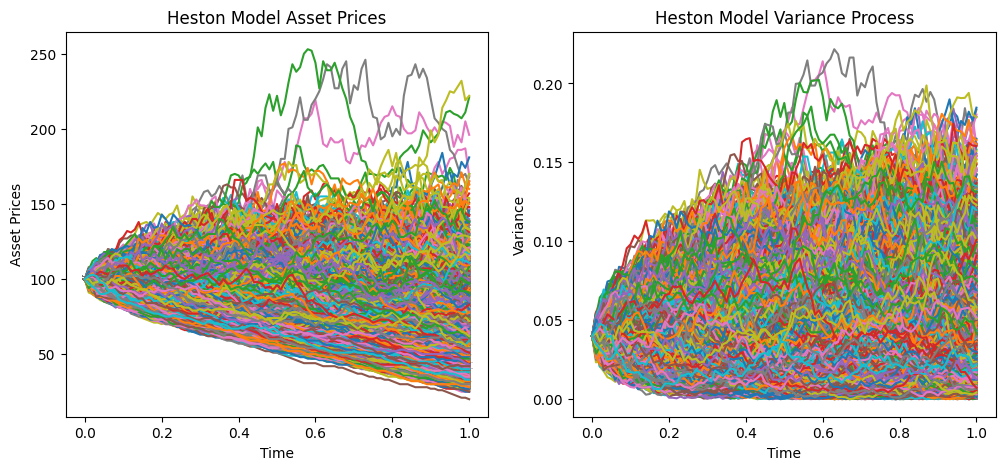

In [ ]:
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize=(12,5))
time = np.linspace(0,T,N+1)
ax1.plot(time,s)
ax1.set_title('Heston Model Asset Prices')
ax1.set_xlabel('Time')
ax1.set_ylabel('Asset Prices')#simulation of stock price over the time 

ax2.plot(time,v)
ax2.set_title('Heston Model Variance Process')
ax2.set_xlabel('Time')
ax2.set_ylabel('Variance')

plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


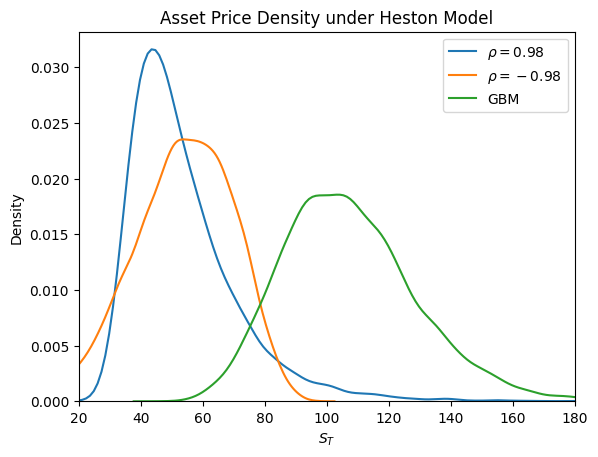

In [20]:
# First simulation with positive correlation
heston_model_pos = HestonUsingMCS(S0, v0, 0.98, kappa, theta, sigma, T, N, M, r, K)
s_pos, v_pos = heston_model_pos.simulate_paths()

# Second simulation with negative correlation
heston_model_neg = HestonUsingMCS(S0, v0, -0.98, kappa, theta, sigma, T, N, M, r, K)
s_neg, v_neg = heston_model_neg.simulate_paths()

# simulate gbm process at time T
gbm = S0*np.exp( (r - theta**2/2)*T + np.sqrt(theta)*np.sqrt(T)*np.random.normal(0,1,M) ) 

# Plotting
fig, ax = plt.subplots()
ax = sns.kdeplot(s_pos[-1], label=r"$\rho= 0.98$", ax=ax)
ax = sns.kdeplot(s_neg[-1], label=r"$\rho= -0.98$", ax=ax)
ax = sns.kdeplot(gbm, label="GBM", ax=ax)

plt.title(r'Asset Price Density under Heston Model')
plt.xlim([20, 180])
plt.xlabel('$S_T$')
plt.ylabel('Density')
plt.legend()
plt.show()

#Positive correlation (ρ = 0.98) leads to fatter left tails, indicating higher probability of large downward moves
# Negative correlation (ρ = -0.98) produces a more balanced distribution 
# Both show asummetric distributions 
# This aligns with the "leverage effect" observed in equity markets where price drops tend to increase volatility


## Implied Volatility Smile

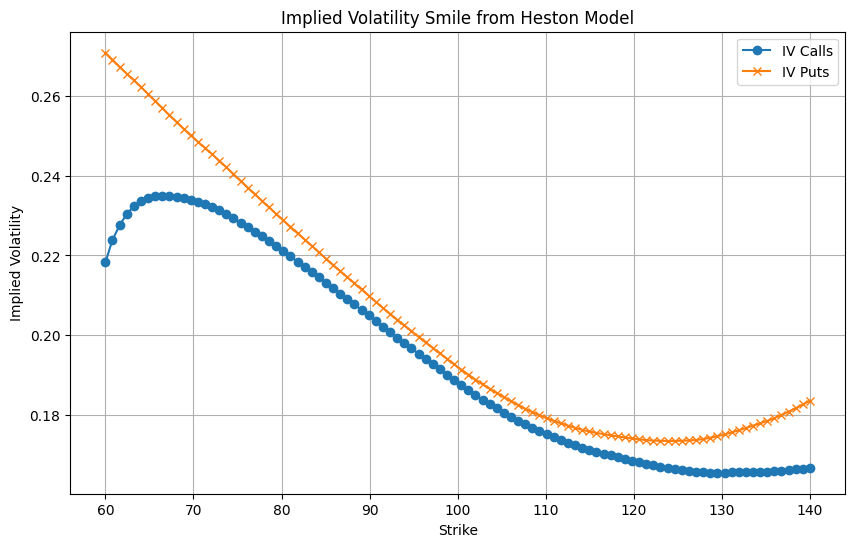

In [ ]:
# Market parameters
S0 = 100.0
r = 0.02
T = 1.0

# Heston parameters - adjusted for higher overall volatility
v0 = 0.04        # Initial variance (20% vol)
kappa = 1.5      # Mean reversion speed
theta = 0.04     # Long-term variance
sigma = 0.4      # Vol-of-vol (increased for more pronounced smile)
rho = -0.5       # Correlation

# Simulation parameters
N = 2000         # Number of time steps
M = 10000        # Number of Monte Carlo paths
K = np.linspace(60, 140, 100)  # Strike range

# Simulate Heston model paths
# Note: Ensure your HestonUsingMCS class returns full paths in S (and variance paths in v)
S, v = HestonUsingMCS(S0, v0, rho, kappa, theta, sigma, T, N, M, r, K).simulate_paths()

# Extract the final asset prices at time T
S_final = S[-1]  # S_final should be a 1D array of terminal prices

# Monte Carlo option pricing using terminal asset prices
puts = np.array([np.exp(-r * T) * np.mean(np.maximum(k - S_final, 0)) for k in K])
calls = np.array([np.exp(-r * T) * np.mean(np.maximum(S_final - k, 0)) for k in K])

# Compute implied volatilities using py_vollib_vectorized
put_ivs = implied_vol(puts, S0, K, T, r, flag='p', q=0, return_as='numpy', on_error='ignore')
call_ivs = implied_vol(calls, S0, K, T, r, flag='c', q=0, return_as='numpy')

# Remove any NaN or non-positive IV values
valid_idx = (~np.isnan(put_ivs)) & (~np.isnan(call_ivs)) & (put_ivs > 0) & (call_ivs > 0)
K_valid = K[valid_idx]
put_ivs = put_ivs[valid_idx]
call_ivs = call_ivs[valid_idx]

# Plot the implied volatility smile
plt.figure(figsize=(10, 6))
plt.plot(K_valid, call_ivs, label='IV Calls', marker='o')
plt.plot(K_valid, put_ivs, label='IV Puts', marker='x')
plt.xlabel('Strike')
plt.ylabel('Implied Volatility')
plt.title('Implied Volatility Smile from Heston Model')
plt.legend()
plt.grid(True)
plt.show()

# Heston Model


Using standard arbitrage arguments we arrive at Garman's partial differential equation:

$\large \frac{\partial C}{\partial t} + \frac{S^2 v}{2}\frac{\partial^2 C}{\partial S^2} + rS\frac{\partial C}{\partial S} - rC + [\kappa(\theta-v)-\lambda v]\frac{\partial C}{\partial v} + \frac{\sigma^2 v}{2}\frac{\partial^2 C}{\partial v^2} + \rho \sigma Sv \frac{\partial^2 C}{\partial S \partial v} = 0$

Heston builds the solution of the PDE above by the method of characteristic functions. He looks for a solution of the form corresponding to the Black-Scholes model:

$\large C(S_0, K, v_0, \tau) = SP_1 - Ke^{-r\tau} P_2$

where:
- $P_1$ is the delta of the European call option
- $P_2$ is the conditional risk neutral probability that the asset price will be greater than K at the maturity

Both probabilities $P_{1,2}$ also satisfy the PDE provided that characteristic functions $\varphi_1$, $\varphi_2$ are known. The terms $P_{1,2}$ are defined via the inverse Fourier transformation:

$\large X = \ln(S)$

$\large P_j = \frac{1}{2} + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[\frac{e^{-i\phi \ln K}\varphi_j(X_0,K,v_0,\tau;\phi)}{i\phi}\right]d\phi, j \in \{1,2\}$

Heston assumes the characteristic functions $\varphi_1$, $\varphi_2$ having the form:

$\large \varphi_j(X_0, K, v_0,\tau; \phi) = e^{C(\tau;\phi)+D(\tau;\phi)v+i\phi X}$

With semianalytical solution:

$\large C(\tau;\phi) = r\phi i \tau + \frac{a}{\sigma^2}[(b_j -\rho\sigma \phi i + d)\tau - 2\ln[\frac{1-ge^{d\tau}}{1-g}]]$

$\large D(\tau;\phi) = \frac{b_j -\rho\sigma \phi i + d}{\sigma^2}\left[\frac{1-e^{d\tau}}{1-ge^{d\tau}}\right]$

where:
- $\large g = \frac{b_j -\rho\sigma \phi i + d}{b_j -\rho\sigma \phi i - d}$
- $\large d = \sqrt{(\rho\sigma \phi i -b_j)^2 - \sigma^2 (2u_j\phi i - \phi^2)}$
- $\large u_1 = 0.5, u_2 = -0.5$
- $\large a = \kappa \theta$
- $\large b_1 = \kappa + \lambda - \rho \sigma$
- $\large b_2 = \kappa + \lambda$

Let's obtain a simplified formula with 1 integral

$\large C(S_0, K, v_0, \tau) = S_0[\frac{1}{2} + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[\frac{e^{-i\phi \ln K}\varphi_1(X_0, K, v_0,\tau;\phi)}{i\phi}\right]d\phi] - Ke^{-r\tau}[\frac{1}{2} + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[\frac{e^{-i\phi \ln K}\varphi_2(X_0, K, v_0,\tau;\phi)}{i\phi}\right]d\phi]$

$\large C(S_0, K, v_0, \tau) = \frac{1}{2}(S_0 - Ke^{-r\tau}) + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[\frac{S_0\varphi_1(\phi)}{i\phi K^{i\phi}} - Ke^{-r\tau}\frac{\varphi_2(\phi)}{i\phi K^{i\phi}}\right]d\phi$

## Let's rearrange $\large \varphi$ & simplify solution to 1 integral

$\large C(S_0, K, v_0, \tau) = \frac{1}{2}(S_0 - Ke^{-r\tau}) + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[e^{r\tau}\frac{\varphi(\phi-i)}{i\phi K^{i\phi}} - K\frac{\varphi(\phi)}{i\phi K^{i\phi}}\right]d\phi$


## Understanding the change in $\varphi$ terms under combined integral
$\large \varphi(X_0, K, v_0,\tau; \phi) = e^{r \phi i \tau} S^{i \phi}[\frac{1-ge^{d\tau}}{1-g}]^{\frac{-2a}{\sigma^2}} exp[\frac{a \tau}{\sigma^2} (b_2 -\rho\sigma \phi i + d) + \frac{v_0}{\sigma^2}(b_2 -\rho\sigma \phi i + d)[\frac{1-e^{d\tau}}{1-ge^{d\tau}}]]$

where d and g no longer change with b1, b2 or u1, u2
- $\large d = \sqrt{(\rho\sigma \phi i - b)^2 + \sigma^2 (\phi i + \phi^2)}$
- $\large g = \frac{b -\rho\sigma \phi i + d}{b -\rho\sigma \phi i - d}$
- $\large a = \kappa \theta$
- $\large b = \kappa + \lambda$

## Understanding the change in d and g terms under combined integral

$\large \varphi_j(X_0, K, v_0,\tau; \phi) = e^{C(\tau;\phi)+D(\tau;\phi)v+i\phi X}$

remember $X = ln(S)$ therefore, $\large e^{i \phi X} = e^{ln(S^{i \phi})} = S^{i \phi}$

$\large C(\tau;\phi) = r\phi i \tau + \frac{a}{\sigma^2}[(b_j -\rho\sigma \phi i + d)\tau - 2ln[\frac{1-ge^{d\tau}}{1-g}])]$

$\large e^{C(\tau;\phi)} = e^{r\phi i \tau} exp[\frac{a}{\sigma^2}(b_j -\rho\sigma \phi i + d)\tau] e^{ln[\frac{1-ge^{d\tau}}{1-g}]^{\frac{-2a}{\sigma^2}})} = e^{r \phi i \tau} [\frac{1-ge^{d\tau}}{1-g}]^{\frac{-2a}{\sigma^2}} exp[\frac{a \tau}{\sigma^2} (b_j -\rho\sigma \phi i + d)]$

$\large D(\tau;\phi) = \frac{b_j -\rho\sigma \phi i + d}{\sigma^2}[\frac{1-e^{d\tau}}{1-ge^{d\tau}}]$

Now let's take a look at $d_j$ and $g_j$ and how they changed with b1,b2 and u1,u2

- $\large d_j = \sqrt{(\rho\sigma \phi i -b_j)^2 - \sigma^2 (2u_j\phi i - \phi^2)}$
- $\large g_j = \frac{b_j -\rho\sigma \phi i + d}{b_j -\rho\sigma \phi i - d}$

For both $d_j$ and $g_j$ how can we reconcile the difference between b1 and b2 calculation. Well this is taken into account by the offset of $\varphi(\phi-i)$ compared to $\varphi(\phi)$. How can this be?

### Understanding change in $b_j$ term to $b$ under combined integral
Let's take a look at the first term of d (within squared brackets -frist squared term) to understand this $\rho\sigma \phi i - b$. When I substitute $\Phi=\phi-i$ into the function $\varphi(\Phi)$
- $\large \rho \sigma (\phi-i) i - b = \rho \sigma (\phi i -i*i) - (\kappa + \lambda) = \rho \sigma (\phi i + 1) - (\kappa + \lambda) = \rho \sigma \phi i - (\kappa + \lambda - \rho \sigma) = \rho \sigma \phi i - b_1$

- $\large \rho \sigma (\phi) i - b) = \rho \sigma \phi i - (\kappa + \lambda) = \rho \sigma \phi i - (\kappa + \lambda ) = \rho \sigma \phi i - b_2$

### Understanding change in $u_j$ term under combined integral
Let's take a look at the second term of d (within squared brackets -second squared term) to understand this $+ \sigma^2 (\phi i + \phi^2)$. When I substitute $\Phi=\phi-i$ into the function $\varphi(\Phi)$

- $\large + \sigma^2 (\phi i + \phi^2) = \sigma^2 ((\phi-i) i + (\phi-i)^2) = \sigma^2 ( \phi i+ 1 + \phi^2-2si-1 ) = \sigma^2 (-\phi i + \phi^2) = - \sigma^2 (2 u_1 \phi i - \phi^2) = - \sigma^2 (2 * 0.5 * \phi i - \phi^2)$

- $\large + \sigma^2 (\phi i + \phi^2) = - \sigma^2 (2 u_2 \phi i - \phi^2) = - \sigma^2 (2 * - 0.5 * \phi i - \phi^2)$

## Part 1 - implement the characteristic function

$\large \varphi(X_0, K, v_0,\tau; \phi) = e^{r \phi i \tau} S^{i \phi}\left[\frac{1-ge^{d\tau}}{1-g}\right]^{\frac{-2a}{\sigma^2}} \exp\left[\frac{a \tau}{\sigma^2} (b_2 -\rho\sigma \phi i + d) + \frac{v_0}{\sigma^2}(b_2 -\rho\sigma \phi i + d)\left[\frac{1-e^{d\tau}}{1-ge^{d\tau}}\right]\right]$

where d and g no longer change with $b_1$, $b_2$ or $u_1$, $u_2$:
- $\large d = \sqrt{(\rho\sigma \phi i - b)^2 + \sigma^2 (\phi i + \phi^2)}$
- $\large g = \frac{b -\rho\sigma \phi i + d}{b -\rho\sigma \phi i - d}$
- $\large a = \kappa \theta$
- $\large b = \kappa + \lambda$

## Part 2 - define the integrand as a function

$\large \int_{0}^{\infty} \Re\left[e^{r\tau}\frac{\varphi(\phi-i)}{i\phi K^{i\phi}} - K\frac{\varphi(\phi)}{i\phi K^{i\phi}}\right]d\phi$

## Part 3 - perform numerical integration over integrand and calculate option price

$\large C(S_0, K, v_0, \tau) = \frac{1}{2}(S_0 - Ke^{-r\tau}) + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[e^{r\tau}\frac{\varphi(\phi-i)}{i\phi K^{i\phi}} - K\frac{\varphi(\phi)}{i\phi K^{i\phi}}\right]d\phi$

## Parameters to determine via calibration with market prices

$\Large \Theta = (v_0, \kappa, \theta, \sigma, \rho, \lambda)$

Minimize squared error:

$\Large \text{SqErr}(\Theta) = \sum^N_{i=1}\sum^M_{j=1}w_{ij}(C_{\text{MP}}(X_i,\tau_j) - C_{\text{SV}}(S_\tau, X_i,\tau_j,r_j,\Theta))^2 + \text{Penalty}(\Theta, \Theta_0)$

- The penalty function may be e.g. the distance to the initial parameter vector $\text{Penalty}(\Theta, \Theta_0) = \|\Theta - \Theta_0\|^2$

## Calibration - Optimization Objective function

$\Large \hat{\Theta} = \underset{\Theta \in U_\Theta}{\text{arg min}} \ \text{SqErr}(\Theta)$

Here we assume that the set of possible combinations of parameters $U_\Theta$ is compact and in the range for which a solution exists.
## Calibration Methods

### 1. Maximum Likelihood:
Log-likelihood function:
$\mathcal{L}(\theta) = -\frac{1}{2}\sum_{i=1}^n \left(\ln(2\pi v_i) + \frac{(r_i - \mu\Delta t)^2}{v_i\Delta t}\right)$

### 2. Root Mean Square Error:
$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n (C_i^{market} - C_i^{model})^2}$

Where:
- $C_i^{market}$ = Market option price
- $C_i^{model}$ = Model option price

Typical ranges for parameters:
- $\kappa$: [1.0, 5.0]
- $\theta$: [0.01, 0.04]
- $\sigma_v$: [0.1, 1.0]
- $\rho$: [-0.9, -0.3]
- $v_0$: [0.01, 0.05]

In [51]:
import numpy as np
from scipy.integrate import quad

class HestonModel:
    def __init__(self, S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r):
        """
        Heston model parameters:
        S0: Initial stock price
        K: Strike price
        v0: Initial variance
        kappa: Rate of mean reversion for variance
        theta: Long-term variance
        sigma: Volatility of variance
        rho: Correlation between stock and variance
        lambd: Risk premium
        tau: Time to maturity
        r: Risk-free rate
        """
        self.S0 = S0
        self.K = K
        self.v0 = v0
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        self.rho = rho
        self.lambd = lambd
        self.tau = tau
        self.r = r
    
    def heston_charfunc(self, phi):
        """Computes the characteristic function of the Heston model."""
        a = self.kappa * self.theta
        b = self.kappa + self.lambd
        rspi = self.rho * self.sigma * phi * 1j
        d = np.sqrt((rspi - b) ** 2 + (phi * 1j + phi ** 2) * self.sigma ** 2)
        g = (b - rspi + d) / (b - rspi - d)
        
        exp1 = np.exp(self.r * phi * 1j * self.tau)
        term2 = self.S0 ** (phi * 1j) * ((1 - g * np.exp(d * self.tau)) / (1 - g)) ** (-2 * a / self.sigma ** 2)
        exp2 = np.exp(a * self.tau * (b - rspi + d) / self.sigma ** 2 + \
                      self.v0 * (b - rspi + d) * ((1 - np.exp(d * self.tau)) / (1 - g * np.exp(d * self.tau))) / self.sigma ** 2)
        
        return exp1 * term2 * exp2
    
    def integrand(self, phi):
        """Defines the integrand function for the Heston model price calculation."""
        numerator = np.exp(self.r * self.tau) * self.heston_charfunc(phi - 1j) - self.K * self.heston_charfunc(phi)
        denominator = 1j * phi * self.K ** (1j * phi)
        return numerator / denominator
    
    def heston_price(self, option_type="call"):
        """Computes the price of a European call or put option using the Heston model."""
        real_integral, err = quad(lambda phi: np.real(self.integrand(phi)), 0, 100)
        #real_integral, err = np.real(quad(self.integrand, 0, 100))
        call_price = (self.S0 - self.K * np.exp(-self.r * self.tau)) / 2 + real_integral / np.pi
        if option_type.lower() == "call":
            return call_price
        elif option_type.lower() == "put":
            return call_price + self.K * np.exp(-self.r * self.tau) - self.S0
        else:
            raise ValueError("Invalid option type. Choose 'call' or 'put'.")


In [52]:
# Parameters to test model
S0 = 100. # initial asset price
K = 100. # strike
v0 = 0.1 # initial variance
r = 0.03 # risk free rate
kappa = 1.5768 # rate of mean reversion of variance process
theta = 0.0398 # long-term mean variance
sigma = 0.3 # volatility of volatility
lambd = 0.575 # risk premium of variance
rho = -0.5711 # correlation between variance and stock process
tau = 1. # time to maturity

In [53]:
heston=HestonModel(S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r)
heston2=HestonUsingMCS(S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r)
heston_model = HestonUsingMCS(S0, v0, rho, kappa, theta, sigma, T, N, M, r, K)#correlation assumed to be 98 percent


In [75]:
print(heston.heston_price())
print(heston.heston_price("put"))
print(heston_model.price_call())
print(heston_model.price_put())


11.54036181935536
8.584915174206174
(0.45401709525763384, 0.032890999063814055)
(26.133780538169532, 0.17016949940052714)


In [91]:
annual_volatility=14.32

In [94]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime as dt
import time

def fetch_nse_data(symbol='NIFTY', max_retries=3):
    """
    Fetch NSE option chain data with retry mechanism and proper headers.
    
    Args:
        symbol (str): Index symbol (NIFTY, BANKNIFTY, etc.)
        max_retries (int): Maximum number of retry attempts
        
    Returns:
        dict: JSON response from NSE API
    """
    url = f"https://www.nseindia.com/api/option-chain-indices?symbol={symbol}"
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9",
        "Accept-Language": "en-US,en;q=0.9",
        "Accept-Encoding": "gzip, deflate, br",
        "Connection": "keep-alive",
        "Referer": "https://www.nseindia.com/option-chain",
        "Upgrade-Insecure-Requests": "1",
        "Cache-Control": "max-age=0"
    }
    
    session = requests.Session()
    
    for attempt in range(max_retries):
        try:
            # First visit the homepage to get cookies
            home_response = session.get(
                "https://www.nseindia.com", 
                headers=headers, 
                timeout=15
            )
            home_response.raise_for_status()
            print(f"Home page status: {home_response.status_code}")
            
            # Then visit the option chain page
            option_page = session.get(
                "https://www.nseindia.com/option-chain", 
                headers=headers, 
                timeout=15
            )
            option_page.raise_for_status()
            print(f"Option chain page status: {option_page.status_code}")
            
            # Wait longer
            time.sleep(3)
            
            # Now fetch the actual API data
            response = session.get(
                url, 
                headers=headers, 
                timeout=15
            )
            response.raise_for_status()
            
            # Debug response content
            print(f"API response status: {response.status_code}")
            print(f"Response content length: {len(response.text)}")
            print(f"Response first 100 chars: {response.text[:100]}")
            
            if response.text.strip():
                return response.json()
            else:
                print(f"Empty response received. Retry {attempt + 1}/{max_retries}")
                time.sleep(5)
                
        except (requests.exceptions.RequestException, ValueError) as e:
            print(f"Error occurred (attempt {attempt + 1}/{max_retries}): {str(e)}")
            if attempt < max_retries - 1:
                time.sleep(5 * (attempt + 1))  # Exponential backoff
            else:
                raise Exception(f"Failed to fetch data after {max_retries} attempts")
    
    return None  # Return None if all attempts fail

def process_option_data(data, target_expiry='24-Apr-2025'):
    """
    Process the NSE option chain data into a pandas DataFrame.
    
    Args:
        data (dict): JSON response from NSE API
        target_expiry (str): Target expiry date in format 'DD-MMM-YYYY'
        
    Returns:
        pd.DataFrame: Processed option chain data
    """
    if data is None:
        raise ValueError("No data received from NSE API")
        
    options_data = []
    S0 = data['records']['underlyingValue']  # Current NIFTY price

    for record in data['records']['data']:
        expiry_date = record['expiryDate']
        if expiry_date == target_expiry:
            strike_price = record['strikePrice']
            bid = record.get('CE', {}).get('bidprice', None)
            ask = record.get('CE', {}).get('askPrice', None)
            iv = record.get('CE', {}).get('impliedVolatility', None)

            if bid and ask:  # Ensure valid bid-ask spread
                mid_price = (bid + ask) / 2
                options_data.append({
                    'expiry_date': expiry_date,
                    'strike': strike_price,
                    'price': mid_price,
                    'iv': iv
                })

    # Convert to DataFrame
    df = pd.DataFrame(options_data)

    if df.empty:
        raise ValueError(f"No data found for expiry date: {target_expiry}")

    # Calculate maturity (time to expiry in years)
    df['maturity'] = df['expiry_date'].apply(lambda x: (dt.strptime(x, '%d-%b-%Y') - dt.today()).days / 365.25)

    # Define risk-free rate (assume a constant rate)
    df['rate'] = 0.06857
    
    return df, S0


In [95]:
data = fetch_nse_data('NIFTY')  # Explicitly set symbol to NIFTY
if data:
    df, S0 = process_option_data(data)

Home page status: 200
Option chain page status: 200
API response status: 200
Response content length: 799359
Response first 100 chars: {"records":{"expiryDates":["09-Apr-2025","17-Apr-2025","24-Apr-2025","30-Apr-2025","08-May-2025","29


In [59]:
# import requests
# import pandas as pd
# import numpy as np
# from scipy.optimize import minimize
# from datetime import datetime as dt

# # Fetch and process the data
# data = fetch_nse_data()
# df, S0 = process_option_data(data)
# # Fetch Nifty Option Chain Data
# url = "https://www.nseindia.com/api/option-chain-indices?symbol=NIFTY"

# # Headers to simulate a browser request
# headers = {
#     "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36",
#     "Accept-Language": "en-US,en;q=0.9",
#     "Accept-Encoding": "gzip, deflate, br"
# }

# # Fetch data from NSE API
# session = requests.Session()
# session.get("https://www.nseindia.com", headers=headers)  # First visit to set cookies
# response = session.get(url, headers=headers)
# data = response.json()  # Parse JSON data

# # User-defined expiry date
# TARGET_EXPIRY = '24-Apr-2025'  

# # Parse data for call options
# options_data = []
# S0 = data['records']['underlyingValue']  # Current NIFTY price

# for record in data['records']['data']:
#     expiry_date = record['expiryDate']
#     if expiry_date == TARGET_EXPIRY:
#         strike_price = record['strikePrice']
#         bid = record.get('CE', {}).get('bidprice', None)
#         ask = record.get('CE', {}).get('askPrice', None)
#         iv = record.get('CE', {}).get('impliedVolatility', None)

#         if bid and ask:  # Ensure valid bid-ask spread
#             mid_price = (bid + ask) / 2
#             options_data.append({
#                 'expiry_date': expiry_date,
#                 'strike': strike_price,
#                 'price': mid_price,
#                 'iv': iv
#             })

# # Convert to DataFrame
# df = pd.DataFrame(options_data)

# if df.empty:
#     print(f"No data found for expiry date: {TARGET_EXPIRY}")
#     exit()

# # Calculate maturity (time to expiry in years)
# df['maturity'] = df['expiry_date'].apply(lambda x: (dt.strptime(x, '%d-%b-%Y') - dt.today()).days / 365.25)

# # Define risk-free rate (assume a constant rate, or use a yield curve function)

# df['rate'] = df['maturity'].apply(0.06857)



JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [96]:
# Extract arrays for calibration
K = df['strike'].to_numpy(dtype=float)
tau = df['maturity'].to_numpy(dtype=float)
P = df['price'].to_numpy(dtype=float)
r = df['rate'].to_numpy(dtype=float)

# Heston Model Calibration Function

def SqErr(x):
    v0, kappa, theta, sigma, rho, lambd = x
    errors = []

    for i in range(len(K)):
        heston = HestonModel(S0, K[i], v0, kappa, theta, sigma, rho, lambd, tau[i], r[i])
        heston_price = heston.heston_price()
        errors.append((P[i] - heston_price) ** 2)

    return np.sum(errors) / len(P)  # Mean Squared Error

# Initial parameter guesses and bounds
params = {
    "v0": {"x0": 0.1, "lbub": [1e-3, 0.1]},
    "kappa": {"x0": 3, "lbub": [1e-3, 5]},
    "theta": {"x0": annual_volatility, "lbub": [1e-3, 0.1]},
    "sigma": {"x0": 0.3, "lbub": [1e-2, 1]},
    "rho": {"x0": -0.8, "lbub": [-1, 0]},
    "lambd": {"x0": 0.03, "lbub": [-1, 1]},
}

x0 = [param["x0"] for param in params.values()]
bnds = [param["lbub"] for param in params.values()]

# Perform optimization (calibration)
result = minimize(SqErr, x0, tol=1e-3, method='SLSQP', options={'maxiter': 1e4}, bounds=bnds)
#sequential least square programming
# Output results
calibrated_params = dict(zip(params.keys(), result.x))
print("Heston Model Calibrated Parameters:")
print(calibrated_params)


Heston Model Calibrated Parameters:
{'v0': 0.1, 'kappa': 3.0, 'theta': 0.1, 'sigma': 0.3, 'rho': -0.8, 'lambd': 0.03}


In [97]:
# Extract optimized parameters
v0_opt, kappa_opt, theta_opt, sigma_opt, rho_opt, lambd_opt = result.x

# Compute model prices using calibrated parameters
df['model_price'] = df.apply(lambda row: HestonModel(
    S0, row['strike'], v0_opt, kappa_opt, theta_opt, sigma_opt, rho_opt, lambd_opt, row['maturity'], row['rate']
).heston_price(), axis=1)

# Compute absolute and relative errors
df['abs_error'] = np.abs(df['price'] - df['model_price'])
df['rel_error'] = df['abs_error'] / df['price'] 

# Display the results
print(df[['strike', 'price', 'model_price', 'abs_error', 'rel_error']])


     strike     price  model_price   abs_error  rel_error
0     20350  2607.075  2708.346659  101.271659   0.038845
1     20400  2561.875  2661.070600   99.195600   0.038720
2     20450  2518.900  2613.959437   95.059437   0.037738
3     20500  2450.275  2567.021181  116.746181   0.047646
4     20550  2268.225  2520.264073  252.039073   0.111117
..      ...       ...          ...         ...        ...
99    25300     3.825    28.499145   24.674145   6.450757
100   25350     3.950    24.301279   20.351279   5.152223
101   25400     3.950    20.339737   16.389737   4.149300
102   25450     3.775    16.604700   12.829700   3.398596
103   25500     3.675    13.086548    9.411548   2.560966

[104 rows x 5 columns]


In [98]:
# Function to calculate R-squared (R²)
def calculate_r_squared(df):
    # Total Sum of Squares (SST)
    sst = np.sum((df['price'] - np.mean(df['price'])) ** 2)
    # Residual Sum of Squares (SSR)
    ssr = np.sum((df['price'] - df['model_price']) ** 2)
    # R-squared
    r_squared = 1 - (ssr / sst)
    return r_squared

# Calculate R²
r_squared = calculate_r_squared(df)

print(f"R-squared: {r_squared}")

R-squared: 0.8978468574090541


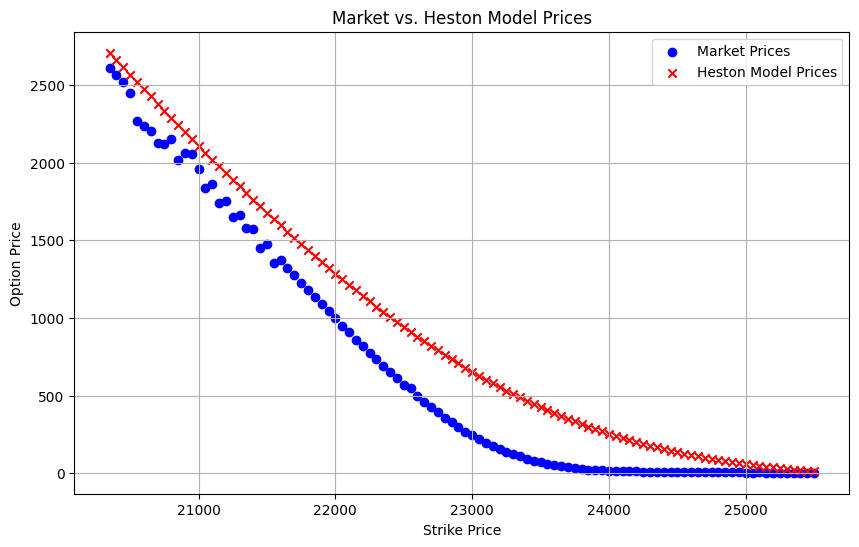

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['strike'], df['price'], label="Market Prices", color='blue', marker='o')
plt.scatter(df['strike'], df['model_price'], label="Heston Model Prices", color='red', marker='x')

plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.title("Market vs. Heston Model Prices")
plt.legend()
plt.grid(True)
plt.show()


In [106]:
data = fetch_nse_data('BANKNIFTY')
target_expiry='24-Apr-2025'
df, S0 = process_option_data(data,target_expiry)

Home page status: 200
Option chain page status: 200
API response status: 200
Response content length: 552653
Response first 100 chars: {"records":{"expiryDates":["24-Apr-2025","29-May-2025","26-Jun-2025","25-Sep-2025","24-Dec-2025","26


In [83]:
# import requests
# import pandas as pd
# import numpy as np
# from scipy.optimize import minimize
# from datetime import datetime as dt

# # Fetch Nifty Option Chain Data
# url = "https://www.nseindia.com/api/option-chain-indices?symbol=NIFTY"

# # Headers to simulate a browser request
# headers = {
#     "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36",
#     "Accept-Language": "en-US,en;q=0.9",
#     "Accept-Encoding": "gzip, deflate, br"
# }

# # Fetch data from NSE API
# session = requests.Session()
# session.get("https://www.nseindia.com", headers=headers)  # First visit to set cookies
# response = session.get(url, headers=headers)
# data = response.json()  # Parse JSON data

# # User-defined expiry date
# TARGET_EXPIRY = '27-Feb-2025'  # Change as needed

# # Parse data for call options
# options_data = []
# S0 = data['records']['underlyingValue']  # Current NIFTY price

# for record in data['records']['data']:
#     expiry_date = record['expiryDate']
#     if expiry_date == TARGET_EXPIRY:
#         strike_price = record['strikePrice']
#         bid = record.get('CE', {}).get('bidprice', None)
#         ask = record.get('CE', {}).get('askPrice', None)
#         iv = record.get('CE', {}).get('impliedVolatility', None)

#         if bid and ask:  # Ensure valid bid-ask spread
#             mid_price = (bid + ask) / 2
#             options_data.append({
#                 'expiry_date': expiry_date,
#                 'strike': strike_price,
#                 'price': mid_price,
#                 'iv': iv
#             })

# # Convert to DataFrame
# df = pd.DataFrame(options_data)

# if df.empty:
#     print(f"No data found for expiry date: {TARGET_EXPIRY}")
#     exit()

# # Calculate maturity (time to expiry in years)
# df['maturity'] = df['expiry_date'].apply(lambda x: (dt.strptime(x, '%d-%b-%Y') - dt.today()).days / 365.25)

# # Define risk-free rate (assume a constant rate, or use a yield curve function)
# def curve_fit(maturity):
#     return 0.06857  
# df['rate'] = df['maturity'].apply(curve_fit)



JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [107]:
v0_opt, kappa_opt, theta_opt, sigma_opt, rho_opt, lambd_opt = result.x
df['model_price'] = df.apply(lambda row: HestonModel(
    S0, row['strike'], v0_opt, kappa_opt, theta_opt, sigma_opt, rho_opt, lambd_opt, row['maturity'], row['rate']
).heston_price(), axis=1)

# Compute absolute and relative errors
df['abs_error'] = np.abs(df['price'] - df['model_price'])
df['rel_error'] = df['abs_error'] / df['price'] 

# Display the results
print(df[['strike', 'price', 'model_price', 'abs_error', 'rel_error']])

     strike      price   model_price   abs_error  rel_error
0     40500  11026.200  11260.366490  234.166490   0.021237
1     41000  10578.625  10761.991140  183.366140   0.017334
2     41500  10012.450  10264.011993  251.561993   0.025125
3     42000   9526.275   9766.612117  240.337117   0.025229
4     42500   9021.400   9270.043450  248.643450   0.027562
..      ...        ...           ...         ...        ...
144   57000      7.650     54.785365   47.135365   6.161486
145   57500      6.500     18.906582   12.406582   1.908705
146   58000      5.825     -8.312799   14.137799   2.427090
147   58500      4.500    -28.547439   33.047439   7.343875
148   59000      4.325    -43.257427   47.582427  11.001717

[149 rows x 5 columns]


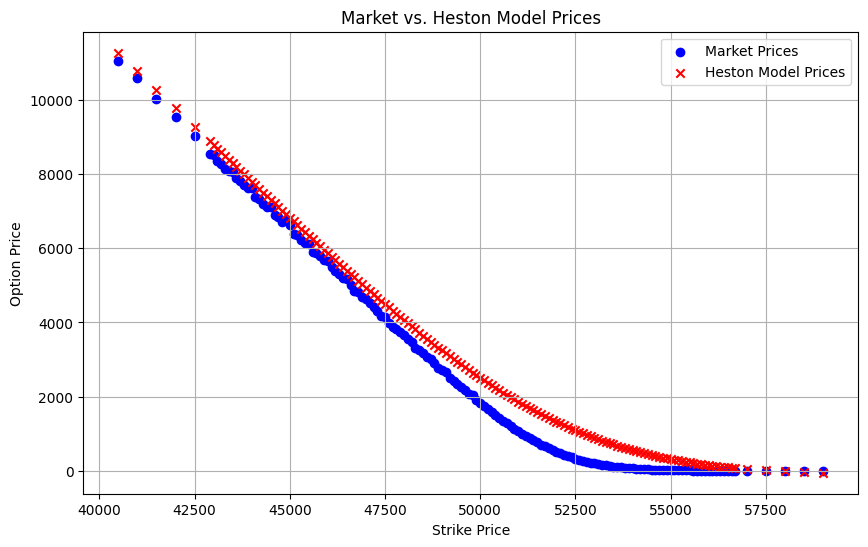

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['strike'], df['price'], label="Market Prices", color='blue', marker='o')
plt.scatter(df['strike'], df['model_price'], label="Heston Model Prices", color='red', marker='x')

plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.title("Market vs. Heston Model Prices")
plt.legend()
plt.grid(True)
plt.show()


In [109]:
# Function to calculate R-squared (R²)
def calculate_r_squared(df):
    # Total Sum of Squares (SST)
    sst = np.sum((df['price'] - np.mean(df['price'])) ** 2)
    # Residual Sum of Squares (SSR)
    ssr = np.sum((df['price'] - df['model_price']) ** 2)
    # R-squared
    r_squared = 1 - (ssr / sst)
    return r_squared

# Calculate R²
r_squared = calculate_r_squared(df)

print(f"R-squared: {r_squared}")

R-squared: 0.9750202132842682


In [110]:
from scipy.optimize import brentq

def implied_volatility(S0, K, v0, kappa, theta, sigma, rho, lambd, tau, market_price, option_type="call"):
    heston_model = HestonModel(S0, K, v0, kappa, theta, sigma, rho, lambd, tau)
    
    # Define the function to find the root
    def objective_function(sigma_guess):
        return heston_model.heston_price(option_type) - market_price
    
    # Use brentq to find the implied volatility
    try:
        iv = brentq(objective_function, 1e-6, 2.0)  # Search for implied volatility between 0 and 2
    except ValueError:
        iv = np.nan  # If no solution is found, return NaN
    
    return iv

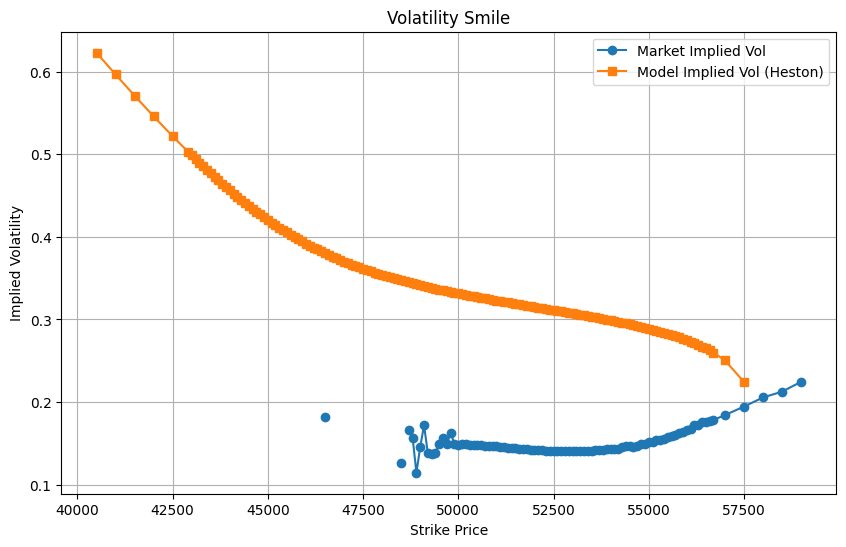

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm

# Black-Scholes implied volatility function
def black_scholes_price(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price

# Function to compute implied volatility
def implied_volatility(price, S, K, T, r, option_type='call'):
    try:
        return brentq(lambda sigma: black_scholes_price(S, K, T, r, sigma, option_type) - price, 1e-6, 5.0)
    except ValueError:
        return np.nan

# Compute implied volatilities
df['implied_vol_market'] = df.apply(lambda row: implied_volatility(row['price'], S0, row['strike'], row['maturity'], row['rate']), axis=1)
df['implied_vol_model'] = df.apply(lambda row: implied_volatility(row['model_price'], S0, row['strike'], row['maturity'], row['rate']), axis=1)

# Plot the volatility smile
plt.figure(figsize=(10, 6))
plt.plot(df['strike'], df['implied_vol_market'], 'o-', label="Market Implied Vol")
plt.plot(df['strike'], df['implied_vol_model'], 's-', label="Model Implied Vol (Heston)")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.legend()
plt.grid()
plt.show()
